# NBA Back-to-Back Fatigue Analysis — 2025–26 Season
Quantifying how schedule fatigue affects player and team performance.

In [51]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, roc_auc_score
from sklearn.model_selection import train_test_split, cross_val_score
from xgboost import XGBClassifier

os.makedirs('../paper/figures', exist_ok=True)
sns.set_theme(style='whitegrid')

## 1. Load Data

In [52]:
pbp      = pd.read_csv('../data/pbp2026.csv', low_memory=False)
schedule = pd.read_csv('../data/LeagueSchedule25_26.csv')

print(f'PBP rows:       {len(pbp):,}')
print(f'Schedule rows:  {len(schedule):,}')

PBP rows:       622,189
Schedule rows:  1,383


In [53]:
# Regular season gameIds start with '225' (NBA season-prefix convention)
schedule = schedule[schedule['gameId'].astype(str).str.startswith('225')].copy()
schedule['gameId'] = schedule['gameId'].astype(str)
schedule['date']   = pd.to_datetime(schedule['gameDateTimeEst']).dt.normalize()

# PBP gameids have leading zeros: '0022500001' -> '22500001'
pbp['gameId'] = pbp['gameid'].apply(lambda x: str(int(x)))

print(f'Regular season games in schedule: {schedule["gameId"].nunique()}')
print(f'Unique games in PBP:              {pbp["gameId"].nunique()}')

Regular season games in schedule: 1230
Unique games in PBP:              1230


## 2. Back-to-Back Flags

In [54]:
# Schedule uses team names (e.g. 'Mavericks'); PBP uses abbreviations (e.g. 'DAL')
team_abbrev = {
    'Hawks': 'ATL', 'Celtics': 'BOS', 'Nets': 'BKN', 'Hornets': 'CHA',
    'Bulls': 'CHI', 'Cavaliers': 'CLE', 'Mavericks': 'DAL', 'Nuggets': 'DEN',
    'Pistons': 'DET', 'Warriors': 'GSW', 'Rockets': 'HOU', 'Pacers': 'IND',
    'Clippers': 'LAC', 'Lakers': 'LAL', 'Grizzlies': 'MEM', 'Heat': 'MIA',
    'Bucks': 'MIL', 'Timberwolves': 'MIN', 'Pelicans': 'NOP', 'Knicks': 'NYK',
    'Thunder': 'OKC', 'Magic': 'ORL', '76ers': 'PHI', 'Suns': 'PHX',
    'Trail Blazers': 'POR', 'Kings': 'SAC', 'Spurs': 'SAS', 'Raptors': 'TOR',
    'Jazz': 'UTA', 'Wizards': 'WAS'
}
schedule['home_abbrev'] = schedule['homeTeamName'].map(team_abbrev)
schedule['away_abbrev'] = schedule['awayTeamName'].map(team_abbrev)

print('Unmapped teams:', schedule['home_abbrev'].isna().sum())

Unmapped teams: 0


In [55]:
# One row per (team, game): home team + away team
home = schedule[['gameId','date','home_abbrev','away_abbrev']].copy()
home = home.rename(columns={'home_abbrev':'team','away_abbrev':'opponent'})
home['is_home'] = 1

away = schedule[['gameId','date','home_abbrev','away_abbrev']].copy()
away = away.rename(columns={'away_abbrev':'team','home_abbrev':'opponent'})
away['is_home'] = 0

team_games = pd.concat([home, away], ignore_index=True)
team_games = team_games.sort_values(['team','date']).reset_index(drop=True)

In [56]:
team_games['prev_date']       = team_games.groupby('team')['date'].shift(1)
team_games['days_rest']       = (team_games['date'] - team_games['prev_date']).dt.days - 1
team_games['is_b2b']          = (team_games['days_rest'] == 0).astype(int)
team_games['days_rest_capped']= team_games['days_rest'].clip(0, 3)

# Add opponent's rest days for the same game
opp = team_games[['gameId','team','days_rest']].rename(
    columns={'team':'opponent','days_rest':'opp_days_rest'})
team_games = team_games.merge(opp, on=['gameId','opponent'])

print(team_games.groupby('team')['is_b2b'].sum().sort_values(ascending=False).to_string())

team
MIA    17
DEN    17
PHX    16
PHI    16
GSW    16
WAS    16
CHA    16
DAL    15
MIL    15
UTA    15
TOR    15
SAS    15
POR    15
NOP    15
LAC    15
MEM    14
BKN    14
LAL    14
MIN    14
CLE    14
NYK    14
OKC    14
ORL    14
SAC    14
HOU    14
CHI    14
DET    14
BOS    13
IND    13
ATL    13


## 3. Per-Player Per-Game Statistics

In [57]:
shots = pbp[pbp['type'].isin(['Made Shot','Missed Shot'])].copy()
shots['made'] = (shots['type'] == 'Made Shot').astype(int)

fg = shots.groupby(['gameId','playerid','player','team']).agg(
    attempts=('made','count'),
    makes=('made','sum')
).reset_index()
fg['fg_pct'] = fg['makes'] / fg['attempts']
fg = fg[fg['attempts'] >= 3].copy()

print(f'Player-game rows (min 3 attempts): {len(fg):,}')

Player-game rows (min 3 attempts): 21,944


In [58]:
# Team turnovers have empty player field — filter those out
to_df = pbp[(pbp['type']=='Turnover') & (pbp['player']!='')].groupby(
    ['gameId','playerid']).size().reset_index(name='turnovers')

foul_df = pbp[(pbp['type']=='Foul') & (pbp['player']!='')].groupby(
    ['gameId','playerid']).size().reset_index(name='fouls')

ft_df = pbp[pbp['type']=='Free Throw'].groupby(
    ['gameId','playerid']).size().reset_index(name='ft_attempts')

In [59]:
player_games = fg.merge(to_df,   on=['gameId','playerid'], how='left')
player_games = player_games.merge(foul_df, on=['gameId','playerid'], how='left')
player_games = player_games.merge(ft_df,   on=['gameId','playerid'], how='left')
player_games[['turnovers','fouls','ft_attempts']] = (
    player_games[['turnovers','fouls','ft_attempts']].fillna(0))
player_games['ft_rate'] = player_games['ft_attempts'] / player_games['attempts']

# Attach schedule context
player_games = player_games.merge(
    team_games[['gameId','team','date','is_b2b','days_rest',
                'days_rest_capped','is_home','opp_days_rest']],
    on=['gameId','team'])

print(f'Total player-game records: {len(player_games):,}')
print(f'B2B records:               {player_games["is_b2b"].sum():,}')

Total player-game records: 21,944
B2B records:               3,943


## 4. Back-to-Back Fatigue Effect

In [60]:
rested = player_games[player_games['is_b2b']==0]
b2b    = player_games[player_games['is_b2b']==1]

t_stat, p_val = stats.ttest_ind(rested['fg_pct'], b2b['fg_pct'])

print(f'Rested FG%:  {rested["fg_pct"].mean():.3f}')
print(f'B2B FG%:     {b2b["fg_pct"].mean():.3f}')
print(f'Drop:        {rested["fg_pct"].mean() - b2b["fg_pct"].mean():.3f}')
print(f't = {t_stat:.3f},  p = {p_val:.4f}')
print(f'\nTurnovers  — rested: {rested["turnovers"].mean():.3f}  B2B: {b2b["turnovers"].mean():.3f}')
print(f'Shot vol.  — rested: {rested["attempts"].mean():.2f}   B2B: {b2b["attempts"].mean():.2f}')

Rested FG%:  0.469
B2B FG%:     0.462
Drop:        0.007
t = 2.181,  p = 0.0292

Turnovers  — rested: 1.454  B2B: 1.464
Shot vol.  — rested: 9.74   B2B: 9.68


In [61]:
# Filters to exclude garbage-time players:
#   - min 5 games in each condition (B2B and rested)
#   - avg >= 6 shot attempts per game (proxy for meaningful minutes)
#   - rested FG% >= 0.35 (filters out players who are just bad shooters)
MIN_GAMES    = 5
MIN_ATTEMPTS = 6
MIN_FG_PCT   = 0.35

fatigue_rows = []
for pid, grp in player_games.groupby('playerid'):
    r = grp[grp['is_b2b']==0]
    b = grp[grp['is_b2b']==1]
    if len(r) < MIN_GAMES or len(b) < MIN_GAMES:
        continue
    avg_attempts  = grp['attempts'].mean()
    rested_fg_pct = r['fg_pct'].mean()
    if avg_attempts < MIN_ATTEMPTS or rested_fg_pct < MIN_FG_PCT:
        continue
    fatigue_rows.append({
        'playerid':        pid,
        'player':          grp['player'].iloc[0],
        'team':            grp['team'].mode()[0],
        'rested_fg_pct':   rested_fg_pct,
        'b2b_fg_pct':      b['fg_pct'].mean(),
        'fatigue_score':   rested_fg_pct - b['fg_pct'].mean(),
        'delta_turnovers': b['turnovers'].mean() - r['turnovers'].mean(),
        'delta_shots':     b['attempts'].mean() - r['attempts'].mean(),
        'avg_attempts':    avg_attempts,
        'n_b2b':           len(b),
        'n_rested':        len(r),
        'season_fg_pct':   grp['fg_pct'].mean()
    })

player_fatigue = pd.DataFrame(fatigue_rows)
print(f'Players qualifying for fatigue scoring: {len(player_fatigue)}')

Players qualifying for fatigue scoring: 303


In [62]:
# Composite index: 50% FG% drop + 25% turnover increase + 25% shot volume drop
def minmax(s):
    return (s - s.min()) / (s.max() - s.min())

player_fatigue['fg_norm']   = minmax(player_fatigue['fatigue_score'])
player_fatigue['to_norm']   = minmax(player_fatigue['delta_turnovers'])
player_fatigue['shot_norm'] = minmax(-player_fatigue['delta_shots'])
player_fatigue['composite'] = (
    0.50 * player_fatigue['fg_norm'] +
    0.25 * player_fatigue['to_norm'] +
    0.25 * player_fatigue['shot_norm']
)

## 5. Player and Team Rankings

In [63]:
top10 = player_fatigue.nlargest(10,'fatigue_score').reset_index(drop=True)

display_cols = {
    'player':        'Player',
    'team':          'Team',
    'avg_attempts':  'Shots/Game',     # avg field goal attempts — proxy for role/minutes
    'rested_fg_pct': 'Rested FG%',     # shooting % when not on a back-to-back
    'b2b_fg_pct':    'B2B FG%',        # shooting % on second night of back-to-back
    'fatigue_score': 'FG% Drop',       # rested minus B2B — higher = worse on B2Bs
    'delta_turnovers':'Extra TOs',     # extra turnovers per game on B2B nights
    'delta_shots':   'Shot Vol Change',# change in attempts per game on B2B nights
    'n_b2b':         'B2B Games',      # how many B2B games this player appeared in
    'composite':     'Composite'
}

t = top10[list(display_cols)].rename(columns=display_cols).copy()
# Convert FG% columns to percentages for readability
for col in ['Rested FG%','B2B FG%','FG% Drop']:
    t[col] = (t[col] * 100).round(1).astype(str) + '%'
t['Shots/Game']     = t['Shots/Game'].round(1)
t['Extra TOs']      = t['Extra TOs'].round(2)
t['Shot Vol Change']= t['Shot Vol Change'].round(1)
t['Composite']      = t['Composite'].round(3)
print(t.to_string(index=False))

          Player Team  Shots/Game Rested FG% B2B FG% FG% Drop  Extra TOs  Shot Vol Change  B2B Games  Composite
      B. Carlson  OKC         6.2      59.8%   27.3%    32.4%      -0.48             -2.7          5      0.767
        K. Jones  IND         6.9      45.6%   23.9%    21.7%       0.75              1.7          6      0.644
         T. Mann  CHA         7.6      39.5%   20.0%    19.5%      -0.38             -1.8          8      0.626
       J. Poeltl  TOR         7.3      73.0%   53.7%    19.3%       0.37             -1.2          7      0.669
    K. Middleton  WAS         8.5      42.3%   27.4%    15.0%      -0.34              0.0          7      0.539
      A. Horford  GSW         7.2      44.5%   30.1%    14.4%      -0.31              2.5          6      0.471
      M. Buzelis  CHI        12.5      48.3%   34.6%    13.6%       0.18             -0.4         14      0.577
K. Caldwell-Pope  MEM         7.3      43.0%   29.4%    13.6%      -0.12              1.3          7    

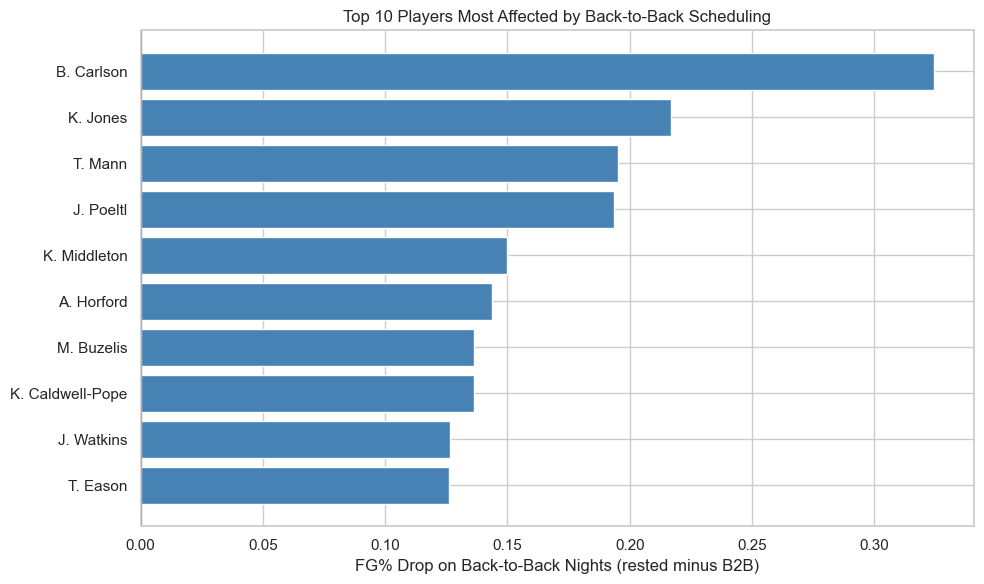

In [64]:
top = player_fatigue.nlargest(10,'fatigue_score').sort_values('fatigue_score')

fig, ax = plt.subplots(figsize=(10,6))
ax.barh(top['player'], top['fatigue_score'], color='steelblue')
ax.set_xlabel('FG% Drop on Back-to-Back Nights (rested minus B2B)')
ax.set_title('Top 10 Players Most Affected by Back-to-Back Scheduling')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig('../paper/figures/fatigue_ranking.pdf', bbox_inches='tight')
plt.show()

In [65]:
# Weighted avg fatigue score per team (weighted by player shot volume)
sw = player_games.groupby(['team','playerid'])['attempts'].sum().reset_index()
sw = sw.merge(player_fatigue[['playerid','fatigue_score','rested_fg_pct','b2b_fg_pct']], on='playerid', how='inner')

def wavg(g, col): return np.average(g[col], weights=g['attempts'])

team_fat = sw.groupby('team').apply(
    lambda g: pd.Series({
        'avg_fg_drop':    wavg(g, 'fatigue_score'),  # avg FG% drop across roster
        'team_rested_fg': wavg(g, 'rested_fg_pct'),  # team FG% on rested nights
        'team_b2b_fg':    wavg(g, 'b2b_fg_pct'),     # team FG% on B2B nights
        'players_tracked': len(g)                    # qualifying players on roster
    })
).reset_index()

b2b_cnt = team_games.groupby('team')['is_b2b'].sum().reset_index(name='b2b_games')
team_summary = team_fat.merge(b2b_cnt, on='team').sort_values('avg_fg_drop', ascending=False)

ts = team_summary.copy()
ts['avg_fg_drop']    = (ts['avg_fg_drop']    * 100).round(2).astype(str) + '%'
ts['team_rested_fg'] = (ts['team_rested_fg'] * 100).round(1).astype(str) + '%'
ts['team_b2b_fg']    = (ts['team_b2b_fg']    * 100).round(1).astype(str) + '%'
ts['players_tracked']= ts['players_tracked'].astype(int)
ts.columns = ['Team','FG% Drop (B2B)','Rested FG%','B2B FG%','Players Tracked','B2B Games']
print(ts.to_string(index=False))

Team FG% Drop (B2B) Rested FG% B2B FG%  Players Tracked  B2B Games
 TOR          4.11%      49.0%   44.9%               10         15
 CHI          3.23%      46.8%   43.6%               16         14
 DAL          3.03%      46.5%   43.5%               13         15
 OKC          2.97%      49.3%   46.3%               14         14
 MIL          2.45%      47.0%   44.6%               11         15
 MEM          2.31%      47.0%   44.6%               14         14
 BOS          2.11%      47.0%   44.9%               11         13
 IND           1.9%      45.8%   43.9%               15         13
 NOP           1.6%      45.2%   43.6%               11         15
 CHA          1.33%      44.7%   43.3%                7         16
 CLE           1.2%      48.7%   47.5%               12         14
 LAC          0.95%      49.1%   48.2%               12         15
 WAS          0.61%      45.3%   44.7%               17         16
 ATL          0.54%      47.7%   47.2%               13       

## 6. K-Means Clustering

In [66]:
feat_cols = ['fatigue_score','delta_turnovers','delta_shots','n_b2b','season_fg_pct']
X = player_fatigue[feat_cols].values

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

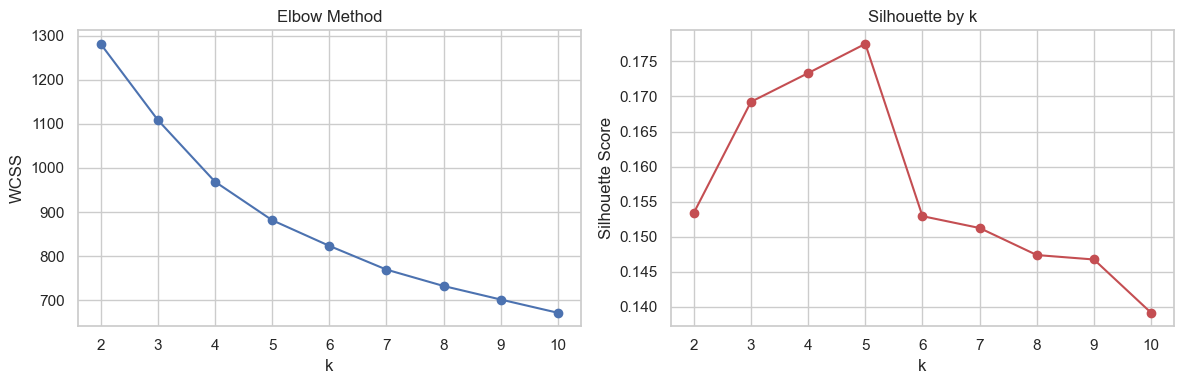

Best k by silhouette: 5  (score = 0.178)


In [67]:
inertias, silhouettes = [], []
K = range(2, 11)

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(list(K), inertias, 'bo-')
ax1.set_xlabel('k'); ax1.set_ylabel('WCSS'); ax1.set_title('Elbow Method')
ax2.plot(list(K), silhouettes, 'ro-')
ax2.set_xlabel('k'); ax2.set_ylabel('Silhouette Score'); ax2.set_title('Silhouette by k')
plt.tight_layout(); plt.show()

best_k = list(K)[silhouettes.index(max(silhouettes))]
print(f'Best k by silhouette: {best_k}  (score = {max(silhouettes):.3f})')

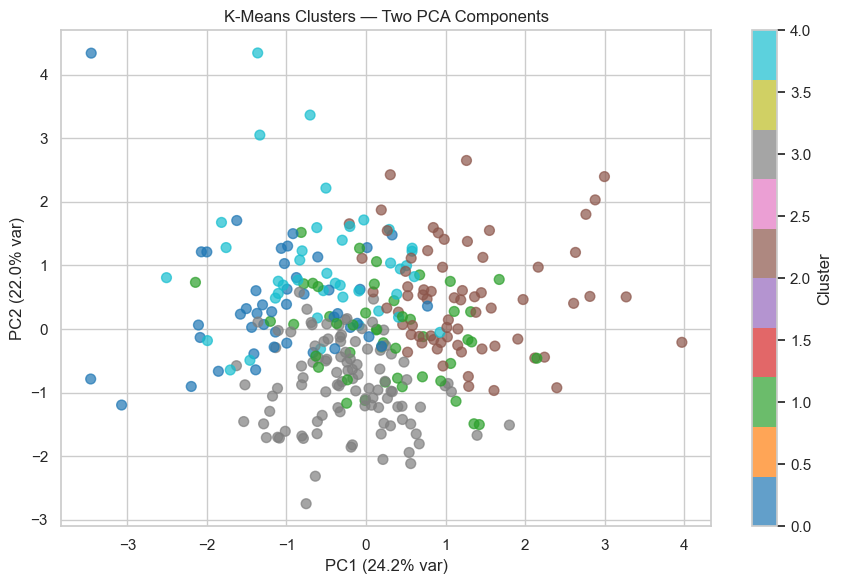

In [68]:
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
player_fatigue['cluster'] = km_final.fit_predict(X_scaled)

pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(X_pca[:,0], X_pca[:,1],
                c=player_fatigue['cluster'], cmap='tab10', alpha=0.7, s=50)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title('K-Means Clusters — Two PCA Components')
plt.colorbar(sc, ax=ax, label='Cluster')
plt.tight_layout()
plt.savefig('../paper/figures/kmeans_clusters.pdf', bbox_inches='tight')
plt.show()

In [69]:
summary = player_fatigue.groupby('cluster')[feat_cols + ['composite']].mean().round(4)
summary['n_players'] = player_fatigue.groupby('cluster').size()
print(summary.to_string())

         fatigue_score  delta_turnovers  delta_shots    n_b2b  season_fg_pct  composite  n_players
cluster                                                                                           
0               0.0717          -0.3662      -0.5252   8.6222         0.4252     0.4762         45
1              -0.0532           0.0942      -0.2168   6.7609         0.4402     0.3852         46
2               0.0223           0.4450       1.5986   8.9706         0.4580     0.4373         68
3              -0.0112          -0.0211       0.1645  13.1165         0.4510     0.4061        103
4               0.0137           0.1207      -0.3922  10.1463         0.5792     0.4558         41


## 7. XGBoost: Predicting Bad Nights

In [70]:
pg = player_games.sort_values(['playerid','date']).copy()

# Rolling FG% entering each game (exclude current game from cumsum)
pg['cumul_makes']    = pg.groupby('playerid')['makes'].cumsum()   - pg['makes']
pg['cumul_attempts'] = pg.groupby('playerid')['attempts'].cumsum()- pg['attempts']
pg['rolling_fg_pct'] = pg['cumul_makes'] / pg['cumul_attempts']

# Cumulative B2B games entering each game
pg['cumul_b2b'] = pg.groupby('playerid')['is_b2b'].cumsum() - pg['is_b2b']

pg = pg.dropna(subset=['rolling_fg_pct','opp_days_rest']).copy()
print(f'Rows available for XGBoost: {len(pg):,}')

Rows available for XGBoost: 21,360


In [71]:
# Target: FG% > 1 std below player's season average = bad night
ps = player_games.groupby('playerid')['fg_pct'].agg(['mean','std']).reset_index()
ps.columns = ['playerid','season_mean','season_std']
pg = pg.merge(ps, on='playerid')

pg['bad_night'] = (pg['fg_pct'] < pg['season_mean'] - pg['season_std']).astype(int)
print(f'Bad nights: {pg["bad_night"].sum():,}  ({pg["bad_night"].mean()*100:.1f}%)')

Bad nights: 3,232  (15.1%)


In [72]:
xgb_feats = ['is_b2b','days_rest_capped','is_home',
             'rolling_fg_pct','cumul_b2b','opp_days_rest']

X_clf = pg[xgb_feats]
y_clf = pg['bad_night']

X_tr, X_te, y_tr, y_te = train_test_split(
    X_clf, y_clf, test_size=0.2, stratify=y_clf, random_state=42)

model = XGBClassifier(n_estimators=200, max_depth=4,
                      learning_rate=0.1, random_state=42)
model.fit(X_tr, y_tr)

baseline_auc = roc_auc_score(y_te, X_te['is_b2b'])
cv_auc       = cross_val_score(model, X_tr, y_tr, cv=5, scoring='roc_auc').mean()
test_auc     = roc_auc_score(y_te, model.predict_proba(X_te)[:,1])

print(f'Baseline AUC (B2B flag only): {baseline_auc:.3f}')
print(f'5-fold CV AUC:                {cv_auc:.3f}')
print(f'Test AUC:                     {test_auc:.3f}')

Baseline AUC (B2B flag only): 0.498
5-fold CV AUC:                0.507
Test AUC:                     0.534


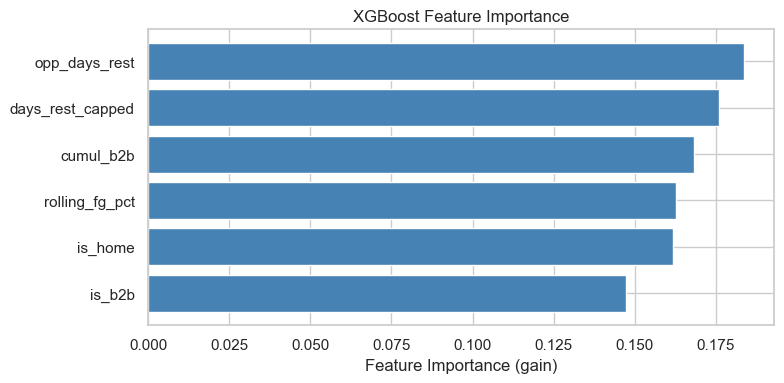

         feature  importance
   opp_days_rest    0.183727
days_rest_capped    0.175968
       cumul_b2b    0.168371
  rolling_fg_pct    0.162856
         is_home    0.161745
          is_b2b    0.147332


In [73]:
imp = pd.DataFrame({'feature': xgb_feats,
                    'importance': model.feature_importances_}).sort_values('importance')

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(imp['feature'], imp['importance'], color='steelblue')
ax.set_xlabel('Feature Importance (gain)')
ax.set_title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

print(imp.sort_values('importance', ascending=False).to_string(index=False))